# Этап 1. EDA датасета обращений в банковскую поддержку

Цель проекта — создать сервис, который по тексту обращения клиента банка определяет категорию обращения.

На этом этапе проведём простой анализ датасета: посмотрим его структуру, классы, пропуски, дубликаты и длину текстов.


## 1. Импорт библиотек

Подключим библиотеки, которые понадобятся для анализа данных и построения графиков.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Загрузка датасета

Загрузим исходный файл и посмотрим первые строки.

In [20]:
from google.colab import files

uploaded = files.upload()

Saving dataset.csv to dataset (3).csv


In [ ]:
df = pd.read_csv(
    'dataset.csv',
    sep=';',
    encoding='cp1251'
)

df.head()

,ID,text,label
0,1,"Регулярный платёж списался частично, остаток в...",PAYMENT_OUT_FAIL
1,2,задержка по кэшбэку уже 9 рабочих дней когда н...,INCOMING_DELAY
2,3,Face ID крутится и возвращает на экран логина....,APP_LOGIN
3,4,аналитика расходов крутится бесконечно данных ...,APP_TECH
4,5,звонили представились банком просили код ничег...,FRAUD_SUSPECTED


## 3. Общая информация о датасете

Посмотрим размер датасета, названия столбцов и типы данных.

In [ ]:
print('Размер датасета:', df.shape)

print('\nСтолбцы:')
print(df.columns.tolist())

print('\nТипы данных:')
print(df.dtypes)

print('\nОбщая информация:')
df.info()

Размер датасета: (1000, 3)

Столбцы:
['ID', 'text', 'label']

Типы данных:
ID        int64
text     object
label    object
dtype: object

Общая информация:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   ID      1000 non-null   int64 
 1   text    1000 non-null   object
 2   label   1000 non-null   object
dtypes: int64(1), object(2)
memory usage: 23.6+ KB


### Вывод

Датасет содержит 1000 строк и 3 столбца:

- `ID` — идентификатор обращения;
- `text` — текст обращения клиента;
- `label` — категория обращения.

Все столбцы загрузились корректно. Для обучения модели основными будут `text` и `label`.

## 4. Проверка пропусков

Проверим, есть ли в данных пустые значения.

Для нашей задачи особенно важны поля `text` и `label`, потому что без текста или категории строку нельзя использовать для обучения модели.

In [ ]:
print('Количество пропусков:')
print(df.isna().sum())

print('\nДоля пропусков, %:')
print((df.isna().mean() * 100).round(2))

Количество пропусков:
ID       0
text     0
label    0
dtype: int64

Доля пропусков, %:
ID       0.0
text     0.0
label    0.0
dtype: float64


### Вывод

Пропущенных значений в датасете нет.

Все 1000 обращений содержат текст и категорию, поэтому удалять строки из-за пропусков не требуется.

## 5. Анализ классов

Посмотрим, сколько категорий обращений есть в датасете и сколько примеров относится к каждой категории.

In [ ]:
class_counts = df['label'].value_counts()

print('Количество классов:', df['label'].nunique())

print('\nКоличество обращений по классам:')
print(class_counts)

print('\nДоля каждого класса, %:')
print(
    (df['label'].value_counts(normalize=True) * 100).round(2)
)

Количество классов: 8

Количество обращений по классам:
label
PAYMENT_OUT_FAIL    131
INCOMING_DELAY      131
APP_LOGIN           131
CARD_ISSUE          129
ACCOUNT_SEIZED      129
FRAUD_SUSPECTED     124
KYC_VERIFICATION    124
APP_TECH            101
Name: count, dtype: int64

Доля каждого класса, %:
label
PAYMENT_OUT_FAIL    13.1
INCOMING_DELAY      13.1
APP_LOGIN           13.1
CARD_ISSUE          12.9
ACCOUNT_SEIZED      12.9
FRAUD_SUSPECTED     12.4
KYC_VERIFICATION    12.4
APP_TECH            10.1
Name: proportion, dtype: float64


### 5.1. Распределение классов

Построим график, чтобы наглядно посмотреть, насколько равномерно представлены разные категории.

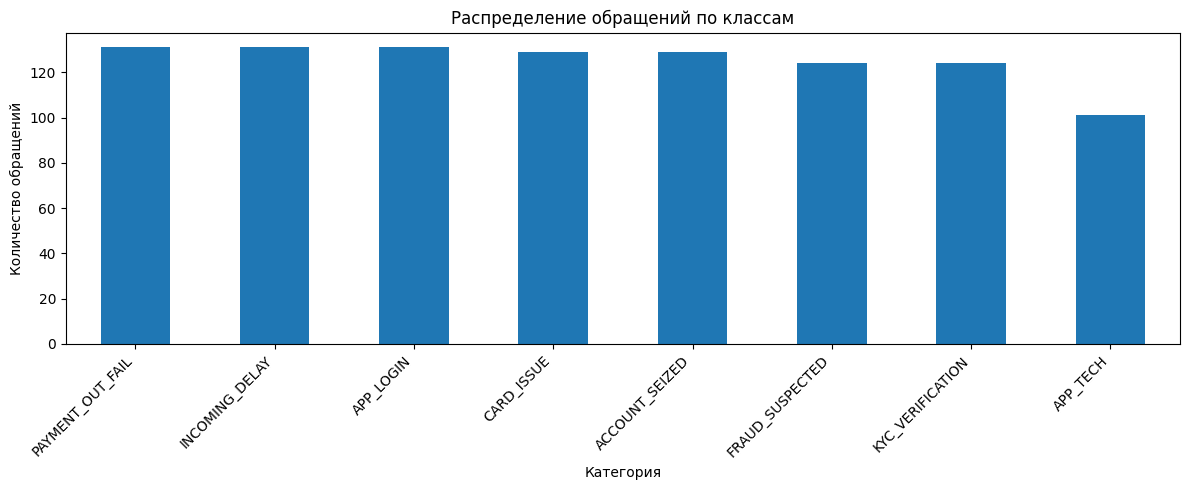

In [ ]:
plt.figure(figsize=(12, 5))

class_counts.plot(kind='bar')

plt.title('Распределение обращений по классам')
plt.xlabel('Категория')
plt.ylabel('Количество обращений')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

### Вывод

В датасете 8 классов обращений.

Количество примеров в каждом классе находится в диапазоне от 101 до 131. Сильного дисбаланса между классами нет, поэтому дополнительные методы балансировки на данном этапе не требуются.

## 6. Проверка дубликатов

Проверим, есть ли полностью одинаковые строки и повторяющиеся тексты обращений.

Это важно, потому что одинаковые тексты не должны случайно попасть одновременно и в обучающую, и в тестовую выборку.

In [ ]:
print(
    'Полных дубликатов строк:',
    df.duplicated().sum()
)

print(
    'Дубликатов по тексту:',
    df['text'].duplicated().sum()
)

### 6.1. Примеры повторяющихся обращений

Посмотрим несколько примеров дубликатов.

In [ ]:
duplicate_texts = (
    df[df.duplicated(subset='text', keep=False)]
    .sort_values('text')
)

duplicate_texts.head(20)

### 6.2. Проверка разметки дубликатов

Проверим, нет ли случаев, когда одинаковый текст относится к разным категориям.

In [ ]:
conflicting_labels = (
    df.groupby('text')['label']
      .nunique()
)

conflicting_labels = conflicting_labels[
    conflicting_labels > 1
]

print(
    'Одинаковых текстов с разными классами:',
    len(conflicting_labels)
)

conflicting_labels.head()

### Вывод

Полных дубликатов строк нет, однако найдено 45 повторов по тексту обращения.

При этом одинаковые тексты всегда относятся к одному и тому же классу — конфликтов в разметке не обнаружено.

На этапе подготовки данных повторяющиеся тексты необходимо удалить до разделения данных на обучающую и тестовую выборки.

## 7. Анализ длины обращений

Посмотрим, насколько длинные сообщения пишут пользователи.

Для этого посчитаем количество символов и слов в каждом обращении.

In [26]:
df['text_length_chars'] = df['text'].str.len()
df['text_length_words'] = df['text'].str.split().str.len()

df[
    ['text_length_chars', 'text_length_words']
].describe()

,text_length_chars,text_length_words
count,1000.000000,1000.000000
mean,61.156000,8.859000
std,11.188156,1.859725
min,38.000000,4.000000
25%,53.000000,8.000000
50%,59.000000,9.000000
75%,67.000000,10.000000
max,107.000000,18.000000


### 7.1. Распределение длины текстов

Построим график по количеству слов в обращениях.

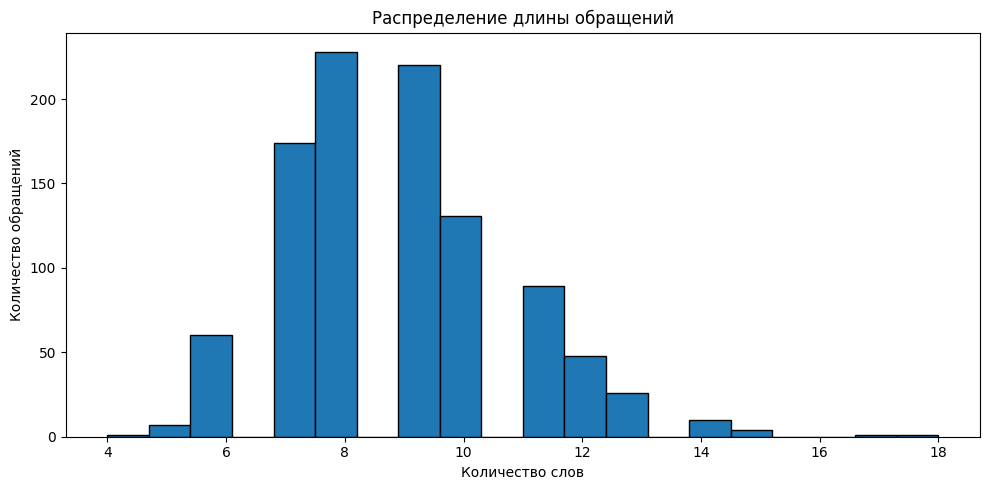

In [27]:
plt.figure(figsize=(10, 5))

plt.hist(
    df['text_length_words'],
    bins=20,
    edgecolor='black'
)

plt.title('Распределение длины обращений')
plt.xlabel('Количество слов')
plt.ylabel('Количество обращений')

plt.tight_layout()
plt.show()

### 7.2. Самые короткие обращения

Посмотрим самые короткие сообщения и проверим, являются ли они нормальными обращениями.

In [28]:
display(
    df.nsmallest(
        10,
        'text_length_words'
    )[
        ['text', 'label', 'text_length_words']
    ]
)

,text,label,text_length_words
297,аналитика расходов крутится бесконечно,APP_TECH,4
292,календарь списаний показывает неверные даты,APP_TECH,5
401,нерезидент подскажите полный перечень документов,KYC_VERIFICATION,5
509,кнопка поделиться реквизитами не реагирует,APP_TECH,5
638,кнопка «Поделиться реквизитами» не реагирует,APP_TECH,5
685,другое гражданство подскажите список документов,KYC_VERIFICATION,5
771,загрузка документа завершается ошибкой 500,APP_TECH,5
981,"веб шустрый, мобильное приложение тормозит",APP_TECH,5
14,онлайн-оплата не проходит пишет карта неактивна,CARD_ISSUE,6
25,платежный календарь показывает неверные даты с...,APP_TECH,6


### 7.3. Самые длинные обращения

Посмотрим самые длинные сообщения и проверим, нет ли среди них необычных значений.

In [29]:
display(
    df.nlargest(
        10,
        'text_length_words'
    )[
        ['text', 'label', 'text_length_words']
    ]
)

,text,label,text_length_words
267,"Перевод по СБП на 8 000 «в обработке» 2 часа, ...",PAYMENT_OUT_FAIL,18
707,Перевод 9 700 ? на карту другого банка завис н...,PAYMENT_OUT_FAIL,17
356,после смены номера телефона приложение просит ...,APP_LOGIN,15
586,зарплата не пришла хотя бухгалтер отправил вед...,INCOMING_DELAY,15
721,Выписка показала списание 1 290 руб. «OnlShop*...,FRAUD_SUSPECTED,15
907,перевод из криптобиржи в фиате отправлен но ба...,INCOMING_DELAY,15
155,не получается войти через веб пишет пользовате...,APP_LOGIN,14
204,Подписка «Music+» списалась три раза по 169 ру...,FRAUD_SUSPECTED,14
366,"Карта не читается в терминале, чип повреждён. ...",CARD_ISSUE,14
413,СМС с кодом входа приходит с задержкой 10–15 м...,APP_LOGIN,14


### Вывод

Обращения в датасете короткие:

- в среднем — около 9 слов;
- медиана — 9 слов;
- минимальная длина — 4 слова;
- максимальная — 18 слов.

Самые короткие и самые длинные обращения выглядят как нормальные пользовательские сообщения. Явных выбросов по длине текста не обнаружено.
Большинство обращений содержит примерно от 8 до 10 слов.

## 8. Примеры обращений по классам

Посмотрим по несколько случайных примеров каждого класса.

Это поможет понять, насколько логично размечены данные и насколько хорошо категории отличаются друг от друга.

In [30]:
for label in df['label'].unique():
    print()
    print(label)

    class_df = df[df['label'] == label]

    examples = class_df.sample(
        n=min(5, len(class_df)),
        random_state=42
    )

    for text in examples['text']:
        print('•', text)


PAYMENT_OUT_FAIL
• перевод юрлицу вернулся банк получателя отказал
• перевод по реквизитам создан но не подписывается кнопка серого цвета
• Платёж на карту другого банка отклонён: «лимит превышен», лимит далеко не исчерпан.
• пополнение кошелька заблокировано mcc запрещён можно временно разрешить
• Покупка в онлайне не прошла, деньги списались и вернулись через минуту. Что это?

INCOMING_DELAY
• возврат за заказ оформили 8 дней назад на счете пусто
• Возврат от магазина прошёл частично, вторая часть не пришла уже неделю.
• кэшбэк завис уже 10 рабочих дней когда начислят
• перевод по номеру у отправителя списался у меня не зачислился
• поступление кредита одобрено но деньги не пришли уже 2 дня

APP_LOGIN
• двухфакторка утеряна коды из приложения-генератора не подходят
• двухфакторка включена, коды из генератора не принимает
• учетная запись найдена но просит старый номер
• при первом входе просит подтвердить устройство а пуш зависает в ожидании
• открываю магический линк на телефоне и 

### Вывод

Примеры обращений в целом соответствуют своим категориям, а смысл классов понятен.

Большинство категорий хорошо отличаются друг от друга. При этом некоторые обращения потенциально могут быть похожи по смыслу, например проблемы со входом и технические проблемы приложения или проблемы с картой и подозрительные операции.

На этапе обучения модели будет интересно проверить, между какими классами возникает больше всего ошибок.

## 9. Итоги EDA

В датасете содержится 1000 обращений клиентов банка, разделённых на 8 категорий.

По результатам анализа:

- пропущенные значения отсутствуют;
- классы распределены достаточно равномерно;
- найдено 45 повторов по тексту обращения;
- одинаковые тексты не имеют конфликтующих категорий;
- обращения короткие — в среднем около 9 слов;
- явных выбросов по длине текста не обнаружено;
- примеры обращений в целом соответствуют своим категориям.

Датасет подходит для дальнейшего обучения модели классификации текстов.

Перед обучением модели необходимо удалить дубликаты и подготовить данные для разделения на обучающую и тестовую выборки.

# Этап 2. Подготовка данных

После EDA подготовим данные для обучения модели.

На этом этапе:

- удалим дубликаты;
- выполним минимальную очистку текста;
- разделим данные на train и test;
- проверим, что между выборками нет утечки данных.

## 1. Формирование рабочего датасета

Для обучения модели нужны только текст обращения и его категория.

`ID` и дополнительные столбцы, которые создавались во время EDA, использовать не будем.

In [31]:
model_df = df[['text', 'label']].copy()

model_df.head()

,text,label
0,"Регулярный платёж списался частично, остаток в...",PAYMENT_OUT_FAIL
1,задержка по кэшбэку уже 9 рабочих дней когда н...,INCOMING_DELAY
2,Face ID крутится и возвращает на экран логина....,APP_LOGIN
3,аналитика расходов крутится бесконечно данных ...,APP_TECH
4,звонили представились банком просили код ничег...,FRAUD_SUSPECTED


## 2. Минимальная очистка текста

Выполним только базовую очистку текста: уберём лишние пробелы.

Сильную обработку текста пока делать не будем, чтобы не потерять полезную информацию.

In [32]:
model_df['text'] = (
    model_df['text']
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
)

In [33]:
print(
    'Пустых текстов после очистки:',
    (model_df['text'] == '').sum()
)

Пустых текстов после очистки: 0


### Вывод

После базовой очистки пустых текстов не появилось.

Все обращения можно использовать дальше.

## 3. Удаление дубликатов

Во время EDA были обнаружены повторяющиеся обращения.

Удалим дубликаты до разделения данных на train и test. Это нужно, чтобы одинаковое обращение не оказалось одновременно в обучающей и тестовой выборках.

In [34]:
print('Количество строк до удаления дубликатов:', len(model_df))

model_df = model_df.drop_duplicates(
    subset='text'
).reset_index(drop=True)

print('Количество строк после удаления дубликатов:', len(model_df))

Количество строк до удаления дубликатов: 1000
Количество строк после удаления дубликатов: 955


In [35]:
print(
    'Осталось дубликатов по тексту:',
    model_df['text'].duplicated().sum()
)

Осталось дубликатов по тексту: 0


### Вывод

Было удалено 45 повторяющихся обращений.

После удаления дубликатов в датасете осталось 955 уникальных текстов.

## 4. Проверка распределения классов

После удаления дубликатов ещё раз проверим количество обращений в каждом классе.

In [36]:
print(model_df['label'].value_counts())

print('\nДоля классов, %:')
print(
    (model_df['label'].value_counts(normalize=True) * 100)
    .round(2)
)

label
APP_LOGIN           131
PAYMENT_OUT_FAIL    129
INCOMING_DELAY      128
CARD_ISSUE          124
ACCOUNT_SEIZED      122
FRAUD_SUSPECTED     115
KYC_VERIFICATION    114
APP_TECH             92
Name: count, dtype: int64

Доля классов, %:
label
APP_LOGIN           13.72
PAYMENT_OUT_FAIL    13.51
INCOMING_DELAY      13.40
CARD_ISSUE          12.98
ACCOUNT_SEIZED      12.77
FRAUD_SUSPECTED     12.04
KYC_VERIFICATION    11.94
APP_TECH             9.63
Name: proportion, dtype: float64


### Вывод

После удаления дубликатов все 8 классов сохранились.

Распределение осталось достаточно равномерным: доля классов составляет примерно от 10% до 14%. Дополнительная балансировка данных не требуется.

## 5. Разделение на обучающую и тестовую выборки

Разделим данные:

- 80% — train;
- 20% — test.

Используем стратификацию, чтобы распределение классов в обеих выборках осталось примерно одинаковым.

In [37]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    model_df,
    test_size=0.2,
    random_state=42,
    stratify=model_df['label']
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print('Размер train:', train_df.shape)
print('Размер test:', test_df.shape)

Размер train: (764, 2)
Размер test: (191, 2)


### 5.1. Проверка классов после разделения

Проверим, что все 8 классов представлены и в train, и в test.

In [38]:
distribution = pd.DataFrame({
    'train': train_df['label'].value_counts(),
    'test': test_df['label'].value_counts()
})

distribution

,train,test
label,,
ACCOUNT_SEIZED,98,24
APP_LOGIN,105,26
APP_TECH,74,18
CARD_ISSUE,99,25
FRAUD_SUSPECTED,92,23
INCOMING_DELAY,102,26
KYC_VERIFICATION,91,23
PAYMENT_OUT_FAIL,103,26


In [39]:
train_share = (
    train_df['label'].value_counts(normalize=True) * 100
).round(2)

test_share = (
    test_df['label'].value_counts(normalize=True) * 100
).round(2)

distribution_percent = pd.DataFrame({
    'train_%': train_share,
    'test_%': test_share
})

distribution_percent

,train_%,test_%
label,,
ACCOUNT_SEIZED,12.83,12.57
APP_LOGIN,13.74,13.61
APP_TECH,9.69,9.42
CARD_ISSUE,12.96,13.09
FRAUD_SUSPECTED,12.04,12.04
INCOMING_DELAY,13.35,13.61
KYC_VERIFICATION,11.91,12.04
PAYMENT_OUT_FAIL,13.48,13.61


### Вывод

Данные были разделены на train и test в соотношении 80/20:

- train — 764 обращения;
- test — 191 обращение.

Благодаря стратификации доли классов в обеих выборках практически одинаковые. Все 8 категорий представлены и в train, и в test.

## 6. Контроль утечки данных

Проверим, что одинаковые обращения не попали одновременно в обучающую и тестовую выборки.

Если такие пересечения есть, оценка качества модели может получиться завышенной.

In [40]:
train_texts = set(train_df['text'])
test_texts = set(test_df['text'])

overlap = train_texts.intersection(test_texts)

print(
    'Количество одинаковых текстов в train и test:',
    len(overlap)
)

Количество одинаковых текстов в train и test: 0


In [41]:
print(
    'Дубликаты внутри train:',
    train_df['text'].duplicated().sum()
)

print(
    'Дубликаты внутри test:',
    test_df['text'].duplicated().sum()
)

Дубликаты внутри train: 0
Дубликаты внутри test: 0


### Вывод

Одинаковых текстов между train и test нет.

Также внутри каждой выборки дубликаты отсутствуют. Таким образом, утечки данных из-за повторяющихся обращений не обнаружено.

## 7. Подготовка данных для модели

Разделим данные на:

- `X` — тексты обращений;
- `y` — категории обращений.

In [42]:
X_train = train_df['text']
y_train = train_df['label']

X_test = test_df['text']
y_test = test_df['label']

print('X_train:', X_train.shape)
print('y_train:', y_train.shape)

print('X_test:', X_test.shape)
print('y_test:', y_test.shape)

X_train: (764,)
y_train: (764,)
X_test: (191,)
y_test: (191,)


### Вывод

Для обучения модели подготовлены:

- `X_train` и `X_test` — тексты обращений;
- `y_train` и `y_test` — категории обращений.

Обучающая выборка содержит 764 примера, тестовая — 191.

## 8. Работа с test-выборкой

Тестовая выборка будет использоваться только для финальной оценки выбранной модели.

TF-IDF и другие преобразования текста будут обучаться только на train-данных.

Для сравнения моделей и параметров на этапе экспериментов будем использовать обучающую выборку и кросс-валидацию.

## 9. Сохранение подготовленных данных

Сохраним train и test отдельно, чтобы использовать одинаковые выборки на следующих этапах проекта.

In [43]:
train_df.to_csv(
    'train.csv',
    index=False,
    encoding='utf-8-sig'
)

test_df.to_csv(
    'test.csv',
    index=False,
    encoding='utf-8-sig'
)

In [44]:
print('train.csv сохранён:', len(train_df), 'строк')
print('test.csv сохранён:', len(test_df), 'строк')

train.csv сохранён: 764 строк
test.csv сохранён: 191 строк


## 10. Итоги подготовки данных

На этапе подготовки данных:

- выполнена базовая очистка текста;
- удалено 45 повторяющихся обращений;
- после удаления дубликатов осталось 955 уникальных текстов;
- баланс 8 классов сохранился;
- данные разделены на train и test в соотношении 80/20;
- train содержит 764 обращения, test — 191;
- между train и test нет одинаковых текстов;
- подготовлены данные для дальнейшего обучения модели.

Тестовая выборка пока не используется и будет нужна для финальной оценки выбранной модели.

Следующий этап — построение baseline-модели.

# Этап 3. Baseline-модель

На этом этапе построим первую базовую модель для классификации обращений.

Будем использовать:

- TF-IDF для преобразования текста в числовые признаки;
- Logistic Regression для классификации обращений;
- 5-fold cross-validation для первой оценки качества модели.

Тестовую выборку пока использовать не будем.

## 1. Выбор baseline-модели

В качестве первого решения используем связку TF-IDF + Logistic Regression.

TF-IDF преобразует тексты в набор числовых признаков и учитывает, насколько важны отдельные слова в документах.

Logistic Regression использует полученные признаки и определяет, к какому из 8 классов относится обращение.

Это простой и распространённый baseline для задачи классификации текста.

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict

from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt
import pandas as pd

## 3. Создание baseline-модели

Объединим TF-IDF и Logistic Regression в один Pipeline.

Pipeline позволяет последовательно преобразовать текст в признаки и передать их модели.

In [22]:
baseline_model = Pipeline([
    (
        'tfidf',
        TfidfVectorizer()
    ),
    (
        'logreg',
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

baseline_model

Pipeline(steps=[('tfidf', TfidfVectorizer()),
                ('logreg', LogisticRegression(max_iter=1000, random_state=42))])

## 4. Cross-validation

Для первой оценки модели используем 5-fold cross-validation.

Обучающая выборка делится на 5 частей. Модель несколько раз обучается на четырёх частях и проверяется на оставшейся.

Стратификация помогает сохранить примерно одинаковое распределение классов в каждом разбиении.

In [23]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

## 5. Метрики качества

Для оценки baseline будем использовать несколько метрик:

- Accuracy — доля правильных предсказаний;
- Precision — насколько точны предсказания модели;
- Recall — насколько хорошо модель находит объекты каждого класса;
- F1-score — объединяет Precision и Recall.

Для Precision, Recall и F1 используем macro average, чтобы каждый класс одинаково влиял на итоговую метрику.

In [24]:
scoring = {
    'accuracy': 'accuracy',
    'precision_macro': 'precision_macro',
    'recall_macro': 'recall_macro',
    'f1_macro': 'f1_macro'
}

## 6. Оценка baseline

Запустим 5-fold cross-validation на обучающей выборке и посчитаем средние значения метрик.

In [45]:
cv_results = cross_validate(
    baseline_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

In [46]:
baseline_metrics = pd.DataFrame({
    'Метрика': [
        'Accuracy',
        'Precision macro',
        'Recall macro',
        'F1 macro'
    ],
    'Среднее значение': [
        cv_results['test_accuracy'].mean(),
        cv_results['test_precision_macro'].mean(),
        cv_results['test_recall_macro'].mean(),
        cv_results['test_f1_macro'].mean()
    ],
    'Стандартное отклонение': [
        cv_results['test_accuracy'].std(),
        cv_results['test_precision_macro'].std(),
        cv_results['test_recall_macro'].std(),
        cv_results['test_f1_macro'].std()
    ]
})

baseline_metrics.round(3)

,Метрика,Среднее значение,Стандартное отклонение
0,Accuracy,0.916,0.024
1,Precision macro,0.921,0.026
2,Recall macro,0.910,0.025
3,F1 macro,0.912,0.026


### Вывод

Baseline показал хорошие результаты:

- Accuracy — 0.916;
- Precision macro — 0.921;
- Recall macro — 0.910;
- F1 macro — 0.912.

Метрики на разных разбиениях отличаются незначительно, поэтому результат модели можно считать достаточно стабильным.

Для простой baseline-модели качество получилось высоким.

## 7. Качество по отдельным классам

Получим предсказания cross-validation и посмотрим Precision, Recall и F1-score отдельно для каждой категории.

In [47]:
cv_predictions = cross_val_predict(
    baseline_model,
    X_train,
    y_train,
    cv=cv
)

In [48]:
print(
    classification_report(
        y_train,
        cv_predictions,
        digits=3
    )
)

                  precision    recall  f1-score   support

  ACCOUNT_SEIZED      0.900     0.918     0.909        98
       APP_LOGIN      0.835     0.962     0.894       105
        APP_TECH      0.930     0.716     0.809        74
      CARD_ISSUE      0.948     0.919     0.933        99
 FRAUD_SUSPECTED      0.944     0.924     0.934        92
  INCOMING_DELAY      0.933     0.951     0.942       102
KYC_VERIFICATION      0.923     0.923     0.923        91
PAYMENT_OUT_FAIL      0.943     0.961     0.952       103

        accuracy                          0.916       764
       macro avg      0.919     0.909     0.912       764
    weighted avg      0.918     0.916     0.915       764



### Вывод

Большинство классов модель определяет хорошо: F1-score для них находится примерно в диапазоне от 0.89 до 0.95.

Лучший результат получен для `PAYMENT_OUT_FAIL` — F1-score 0.952.

Самым сложным классом оказался `APP_TECH` — F1-score 0.809 и Recall 0.716. Поэтому отдельно посмотрим, с какими категориями модель чаще всего его путает.

## 8. Матрица ошибок

Построим confusion matrix, чтобы посмотреть, какие категории модель чаще всего путает между собой.

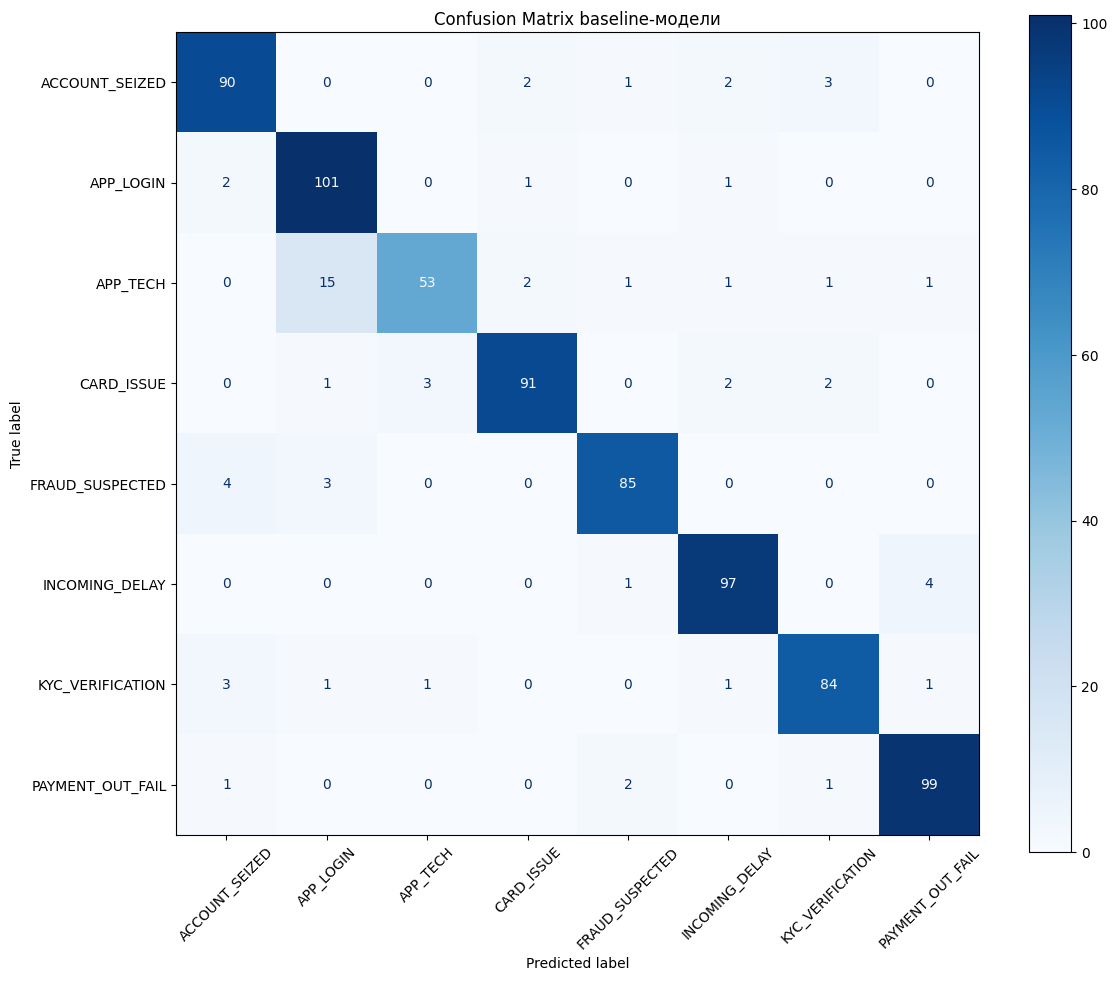

In [49]:
fig, ax = plt.subplots(figsize=(12, 10))

ConfusionMatrixDisplay.from_predictions(
    y_train,
    cv_predictions,
    xticks_rotation=45,
    cmap='Blues',
    ax=ax
)

plt.title('Confusion Matrix baseline-модели')
plt.tight_layout()
plt.show()

### Вывод

Основная ошибка baseline-модели связана с классами `APP_TECH` и `APP_LOGIN`.

Из 74 обращений категории `APP_TECH` модель 15 раз отнесла их к `APP_LOGIN`.

Остальные классы модель различает значительно лучше, а ошибки между ними в основном единичные.

Таким образом, главным направлением для улучшения модели является более точное разделение технических проблем приложения и проблем со входом.

## 9. Примеры ошибок модели

Посмотрим несколько обращений, которые baseline классифицировал неправильно.

In [50]:
errors = pd.DataFrame({
    'text': X_train.values,
    'true_label': y_train.values,
    'predicted_label': cv_predictions
})

errors = errors[
    errors['true_label'] != errors['predicted_label']
]

print('Количество ошибок:', len(errors))

errors.head(15)

Количество ошибок: 64


,text,true_label,predicted_label
5,поле комментария обрезает текст после 40–50 си...,APP_TECH,APP_LOGIN
14,ошибка tls при подключении через общественный ...,APP_TECH,APP_LOGIN
40,сканер qr не запускается нет доступа к камере ...,APP_TECH,INCOMING_DELAY
50,договоры и счета-фактуры загрузил подтвердите ...,ACCOUNT_SEIZED,KYC_VERIFICATION
74,операции по мелким суммам списались подряд без...,FRAUD_SUSPECTED,ACCOUNT_SEIZED
99,запрос на подтверждение адреса завис уже трети...,KYC_VERIFICATION,INCOMING_DELAY
104,поле комментария обрезает текст после ~50 симв...,APP_TECH,APP_LOGIN
106,перевод по номеру телефона задерживается у отп...,INCOMING_DELAY,PAYMENT_OUT_FAIL
118,перевод по номеру у отправителя списался у мен...,INCOMING_DELAY,PAYMENT_OUT_FAIL
142,получил письмо подтвердить аккаунт перешёл бою...,FRAUD_SUSPECTED,APP_LOGIN


### Вывод

Всего baseline допустил 64 ошибки на 764 обращениях.

Часть ошибок возникает между близкими по смыслу категориями. Особенно часто технические проблемы приложения (`APP_TECH`) определяются как проблемы со входом (`APP_LOGIN`).

Анализ ошибок подтверждает результаты confusion matrix и показывает, какие классы стоит попытаться улучшить на этапе экспериментов.

## 10. Обучение baseline на всей train-выборке

После оценки через cross-validation обучим baseline-модель на всей обучающей выборке.

Тестовую выборку пока оставляем для финальной оценки выбранной модели.

In [51]:
baseline_model.fit(
    X_train,
    y_train
)

print('Baseline-модель обучена.')

Baseline-модель обучена.


### Вывод

Baseline-модель успешно обучена на всей train-выборке.

Теперь её результаты можно использовать как базовый уровень для сравнения следующих экспериментов.

## 11. Итоги baseline

На этом этапе была построена baseline-модель `TF-IDF + Logistic Regression`.

Модель оценивалась с помощью 5-fold cross-validation только на train-выборке. Test-данные не использовались.

Основные результаты:

- Accuracy — 0.916;
- Precision macro — 0.921;
- Recall macro — 0.910;
- F1 macro — 0.912;
- всего получено 64 ошибочных предсказания из 764;
- основной проблемой стало разделение классов `APP_TECH` и `APP_LOGIN`.

Для первой модели без дополнительной настройки результат получился хорошим.

Полученные метрики будут использоваться как baseline для сравнения следующих экспериментов.